In [4]:
import numpy as np
import numpy as np
import os
os.environ["picaso_refdata"]="/Users/ihuckabee/Documents/picaso-master/reference"
os.environ['PYSYN_CDBS']="/Users/ihuckabee/Documents/picaso-master/grp/redcat/trds"
refdata = os.getenv("picaso_refdata")
import pdb
from virga import justdoit as vdi
import pandas as pd
import astropy.units as u
from picaso import justplotit as ppi
from picaso import justdoit as pdi
import pandas as pd
#import xesmf as xe
import xarray as xr
from bokeh.plotting import show, figure

In [5]:
opacity = pdi.opannection(wave_range=[1.1,1.7])

In [6]:
gcm_out =  pdi.HJ_pt_3d(as_xarray=True)
case_3d = pdi.inputs()
case_3d.phase_angle(0, num_gangle=10, num_tangle=10)
case_3d.atmosphere_3d(gcm_out,regrid=True,plot=False,verbose=False)
case_3d.chemeq_3d(n_cpu=5) #parallelize chemistry run
case_3d.gravity(radius=1,radius_unit=pdi.u.Unit('R_jup'),
                mass=1, mass_unit=pdi.u.Unit('M_jup')) #any astropy units available
case_3d.star(opacity,5000,0,4.0, radius=1, radius_unit=pdi.u.Unit('R_sun'))

/Users/ihuckabee/anaconda3/lib/python3.10/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


In [7]:
out3d = case_3d.spectrum(opacity,calculation='thermal',dimension='3d',full_output=True)

In [8]:
wno,fpfs = pdi.mean_regrid(out3d['wavenumber'],out3d['fpfs_thermal'],R=100)
ppi.show(ppi.spectrum(wno, fpfs*1e6, plot_width=500,y_axis_type='log'))

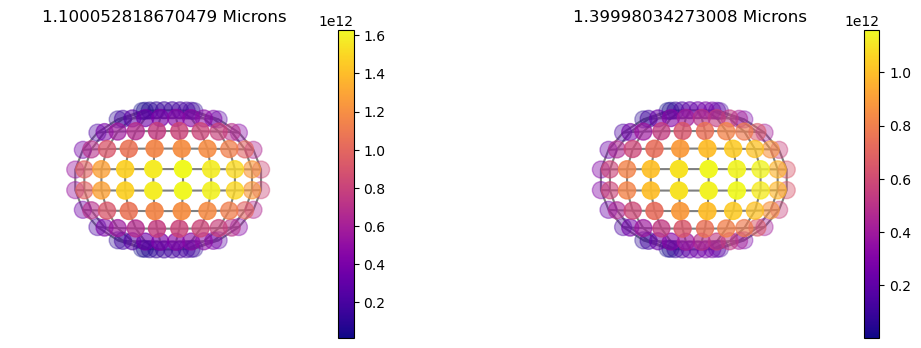

In [9]:
ppi.disco(out3d['full_output'] ,wavelength=[1.1, 1.4], calculation='thermal')